# Healthcare Analytics for Doctor Visits
**Student:** <your name> &nbsp;|&nbsp; **Dataset:** 5,190 patient records, 13 columns

## Problem Statement
Hospitals and insurers struggle to understand why some patients visit a doctor far more often than others. This project analyzes patient data (age, income, illness, chronic conditions, coverage) to find which factors drive doctor visits, and builds a simple model to flag high-visit patients.

## 1. Setup and Load Data
Run this cell, then **upload the CSV** when prompted (Colab only).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')

FILE = '1776250375-P2-Healthcare_Analytics_for_Doctor_Visits.csv'   # your dataset (Colab will ask you to upload it)
try:
    from google.colab import files
    import os
    if not os.path.exists(FILE):
        up = files.upload()               # pick the CSV in the popup
        FILE = list(up.keys())[0]
except ImportError:
    pass                                   # running locally

df = pd.read_csv(FILE)
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## 2. Understand the Data

In [2]:
print('Shape:', df.shape)
df.info()

Shape: (5190, 13)
<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 527.2 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5190.0,2595.500000,1498.368279,1.00,1298.25,2595.50,3892.75,5190.00
visits,5190.0,0.301734,0.798134,0.00,0.00,0.00,0.00,9.00
age,5190.0,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,0.583160,0.368907,0.00,0.25,0.55,0.90,1.50
illness,5190.0,1.431985,1.384152,0.00,0.00,1.00,2.00,5.00
reduced,5190.0,0.861850,2.887628,0.00,0.00,0.00,0.00,14.00
health,5190.0,1.217534,2.124266,0.00,0.00,0.00,2.00,12.00


**Column notes:** `age` and `income` are stored as scaled values (age/100 and income/10,000), so 0.19 means about 19 years old. `visits` is a count with many zeros.

## 3. Data Cleaning

In [4]:
# drop the record-ID column (not a health measurement)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print('Missing values:', df.isna().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

# convert yes/no columns to 1/0 and make real-world age
yn_cols = ['private','freepoor','freerepat','nchronic','lchronic']
for c in yn_cols:
    df[c] = df[c].map({'yes':1,'no':0})
df['age_years'] = (df['age']*100).round()
df['income_level'] = df['income']*10000     # approx annual income
df['gender_num'] = df['gender'].map({'male':1,'female':0})

# helper groups for analysis
df['visited'] = (df['visits']>0).astype(int)
df['age_group'] = pd.cut(df['age_years'], [0,20,35,50,65,100],
                         labels=['<20','20-35','36-50','51-65','65+'])
df.head()

Missing values: 0
Duplicate rows: 1320


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,age_years,income_level,gender_num,visited,age_group
0,1,female,0.19,0.55,1,4,1,1,0,0,0,0,19.0,5500.0,0,1,<20
1,1,female,0.19,0.45,1,2,1,1,0,0,0,0,19.0,4500.0,0,1,<20
2,1,male,0.19,0.90,3,0,0,0,0,0,0,0,19.0,9000.0,1,1,<20
3,1,male,0.19,0.15,1,0,0,0,0,0,0,0,19.0,1500.0,1,1,<20
4,1,male,0.19,0.45,2,5,1,0,0,0,1,0,19.0,4500.0,1,1,<20


## 4. Exploratory Data Analysis

### 4.1 How many doctor visits do people have?

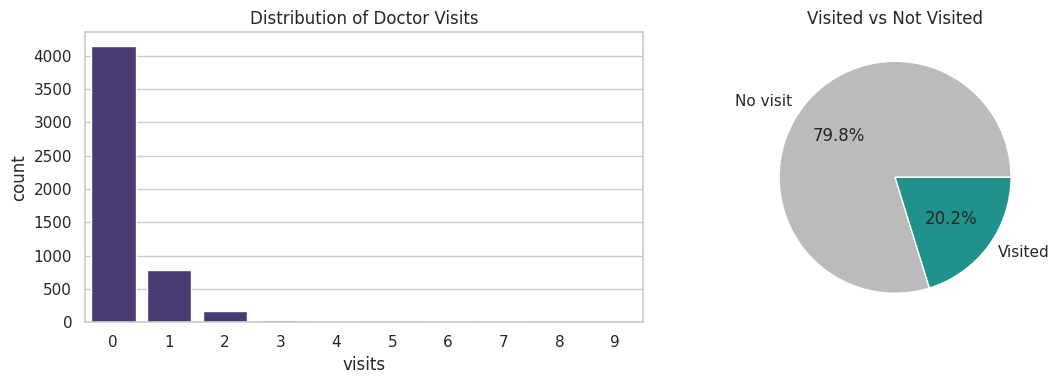

Average visits: 0.3


In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.countplot(x='visits', data=df, ax=ax[0])
ax[0].set_title('Distribution of Doctor Visits')
df['visited'].map({0:'No visit',1:'Visited'}).value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax[1], colors=['#bbb','#21918c'])
ax[1].set_ylabel(''); ax[1].set_title('Visited vs Not Visited')
plt.tight_layout(); plt.show()
print('Average visits:', round(df.visits.mean(),2))

**Insight:** Most people have 0 visits, and a small group visits many times. That small group is what a healthcare provider cares about.

### 4.2 Personal factors: age and gender

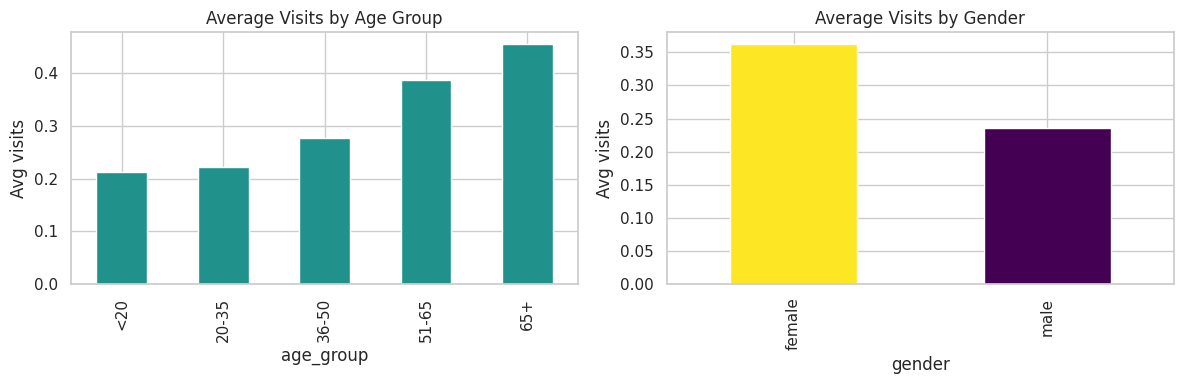

In [6]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
df.groupby('age_group')['visits'].mean().plot.bar(ax=ax[0], color='#21918c')
ax[0].set_title('Average Visits by Age Group'); ax[0].set_ylabel('Avg visits')
df.groupby('gender')['visits'].mean().plot.bar(ax=ax[1], color=['#fde725','#440154'])
ax[1].set_title('Average Visits by Gender'); ax[1].set_ylabel('Avg visits')
plt.tight_layout(); plt.show()

### 4.3 Health factors: illness, reduced activity, health score

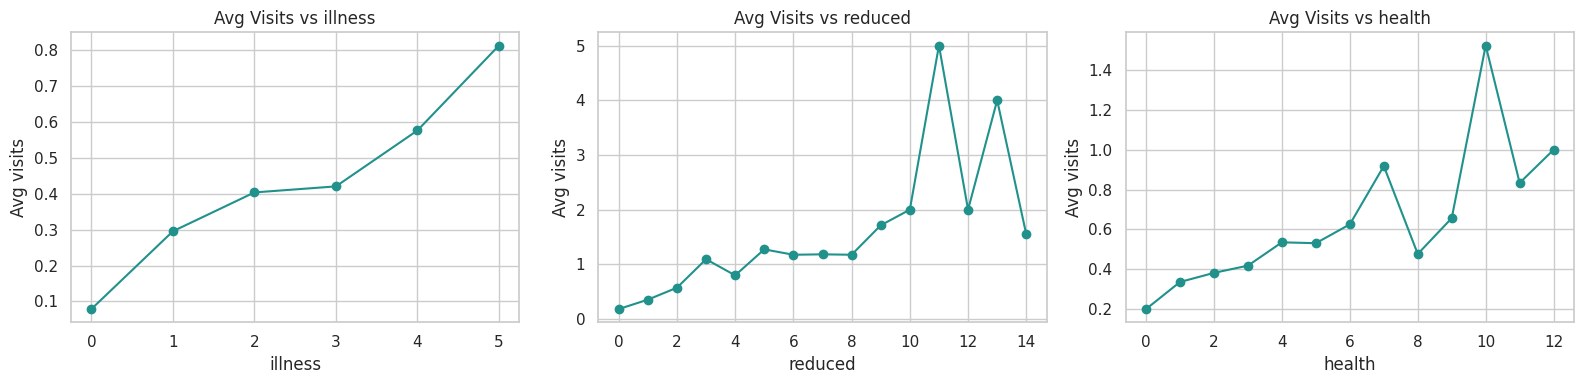

In [7]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
for a, col in zip(ax, ['illness','reduced','health']):
    df.groupby(col)['visits'].mean().plot(marker='o', ax=a, color='#21918c')
    a.set_title(f'Avg Visits vs {col}'); a.set_ylabel('Avg visits')
plt.tight_layout(); plt.show()

**Insight:** Visits tend to rise with the number of illnesses, days of reduced activity, and the health-problem score.

### 4.4 Chronic conditions

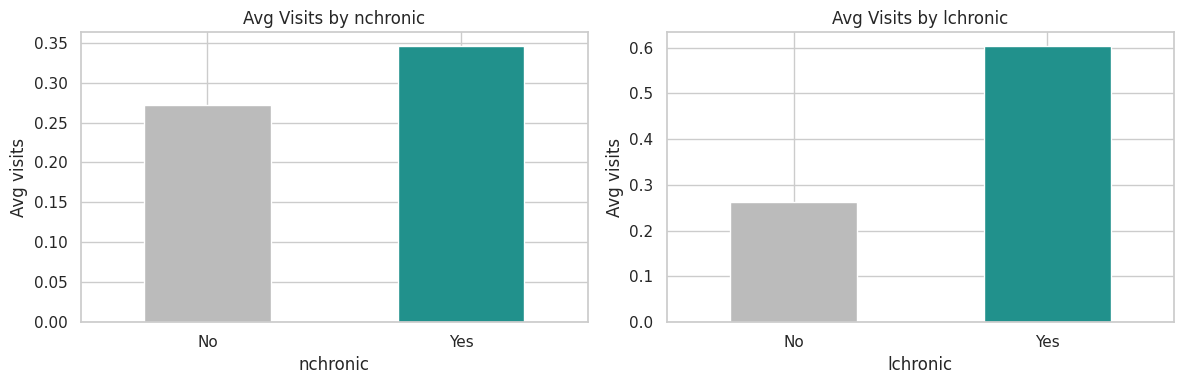

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
for a, col in zip(ax, ['nchronic','lchronic']):
    df.groupby(col)['visits'].mean().rename({0:'No',1:'Yes'}).plot.bar(ax=a, color=['#bbb','#21918c'])
    a.set_title(f'Avg Visits by {col}'); a.set_ylabel('Avg visits'); a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

### 4.5 Income and healthcare coverage

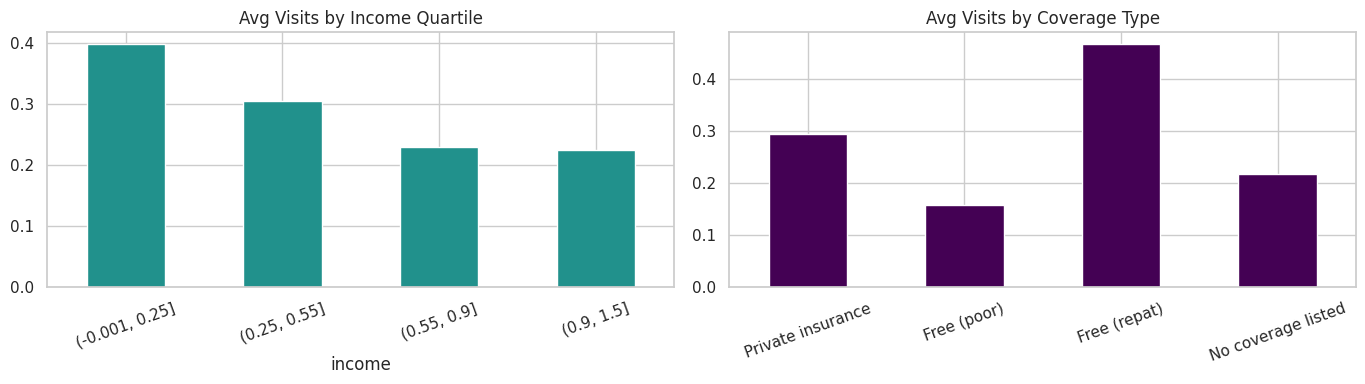

,Avg visits
Private insurance,0.294604
Free (poor),0.157658
Free (repat),0.466544
No coverage listed,0.218493


In [9]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
df.groupby(pd.qcut(df['income'], 4, duplicates='drop'))['visits'].mean().plot.bar(ax=ax[0], color='#21918c')
ax[0].set_title('Avg Visits by Income Quartile'); ax[0].tick_params(axis='x', rotation=20)

cov = pd.DataFrame({
    'Private insurance': df[df.private==1].visits.mean(),
    'Free (poor)': df[df.freepoor==1].visits.mean(),
    'Free (repat)': df[df.freerepat==1].visits.mean(),
    'No coverage listed': df[(df.private==0)&(df.freepoor==0)&(df.freerepat==0)].visits.mean()
}, index=['Avg visits']).T
cov.plot.bar(ax=ax[1], legend=False, color='#440154')
ax[1].set_title('Avg Visits by Coverage Type'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
cov

### 4.6 Correlation with visits

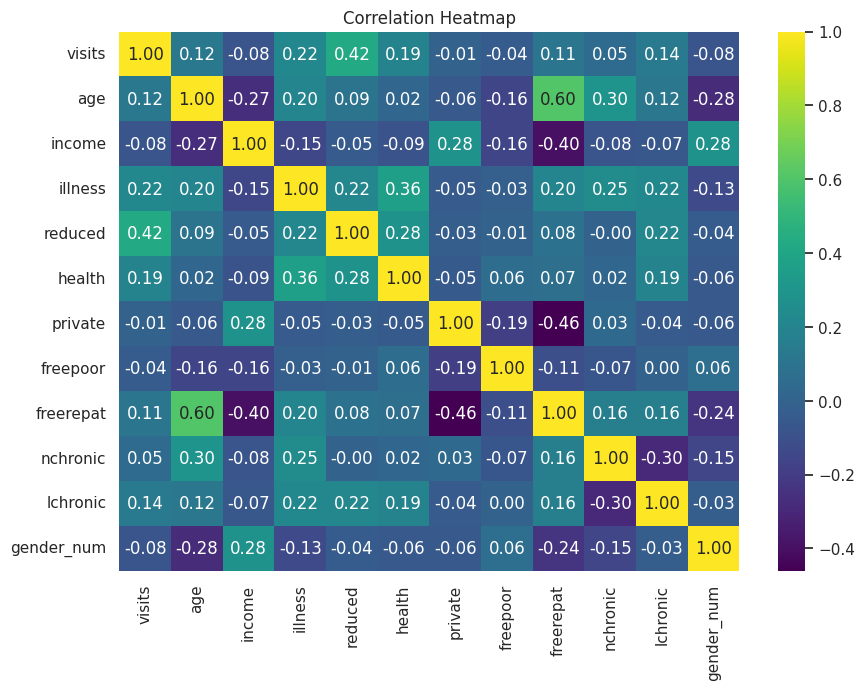

Correlation with visits:


reduced       0.418954
illness       0.223552
health        0.193272
lchronic      0.137267
age           0.124537
freerepat     0.106543
nchronic      0.045171
private      -0.007964
freepoor     -0.038163
income       -0.076840
gender_num   -0.078637
Name: visits, dtype: float64

In [10]:
num = ['visits','age','income','illness','reduced','health','private','freepoor','freerepat','nchronic','lchronic','gender_num']
corr = df[num].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis')
plt.title('Correlation Heatmap'); plt.show()

print('Correlation with visits:')
corr['visits'].drop('visits').sort_values(ascending=False)

## 5. Predictive Model
Goal: predict whether a patient is a **frequent visitor** (1+ visits) from their profile.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

features = ['age','income','illness','reduced','health','private','freepoor','freerepat','nchronic','lchronic','gender_num']
X, y = df[features], df['visited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42)
}
results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results[name] = accuracy_score(y_test, pred)
    print(f'--- {name} ---')
    print(classification_report(y_test, pred, target_names=['No visit','Visited']))
pd.Series(results, name='Accuracy')

--- Logistic Regression ---
              precision    recall  f1-score   support

    No visit       0.88      0.75      0.81       828
     Visited       0.37      0.60      0.46       210

    accuracy                           0.71      1038
   macro avg       0.63      0.67      0.63      1038
weighted avg       0.78      0.71      0.74      1038



--- Random Forest ---
              precision    recall  f1-score   support

    No visit       0.88      0.77      0.82       828
     Visited       0.39      0.60      0.47       210

    accuracy                           0.73      1038
   macro avg       0.64      0.68      0.65      1038
weighted avg       0.78      0.73      0.75      1038



Logistic Regression    0.714836
Random Forest          0.732177
Name: Accuracy, dtype: float64

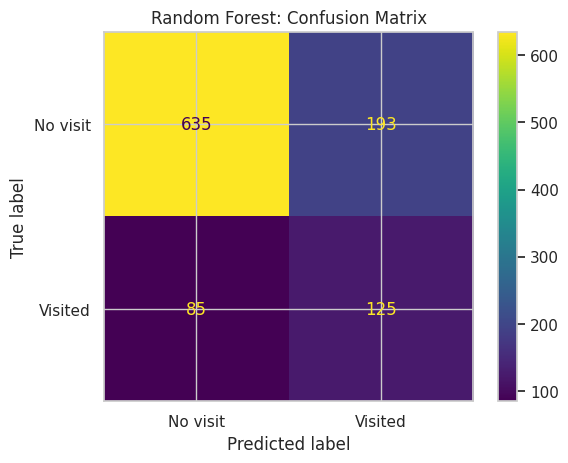

In [12]:
rf = models['Random Forest']
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=['No visit','Visited'], cmap='viridis')
plt.title('Random Forest: Confusion Matrix'); plt.show()

### Which factors matter most?

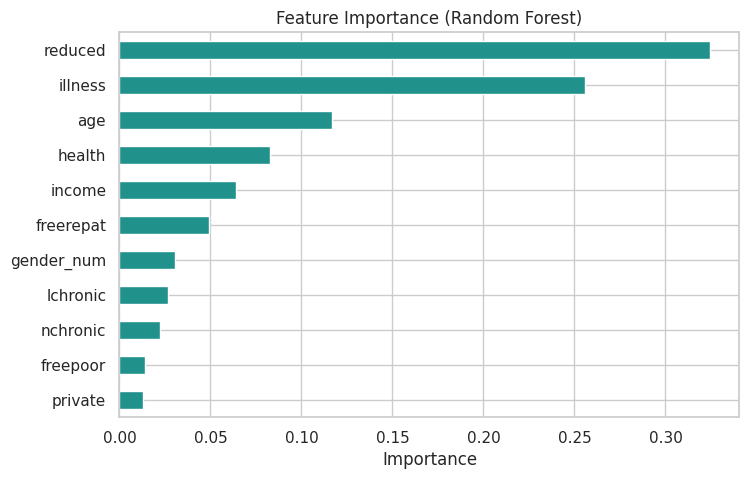

reduced       0.324412
illness       0.255617
age           0.116957
health        0.082956
income        0.064284
freerepat     0.049227
gender_num    0.030440
lchronic      0.026842
nchronic      0.022045
freepoor      0.014241
private       0.012979
dtype: float64

In [13]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot.barh(figsize=(8,5), color='#21918c')
plt.title('Feature Importance (Random Forest)'); plt.xlabel('Importance'); plt.show()
imp.sort_values(ascending=False)

## 6. Key Findings and Conclusion

In [14]:
top = imp.sort_values(ascending=False).head(3).index.tolist()
print('Top 3 drivers of doctor visits:', top)
print(f"Share of people with at least one visit: {df.visited.mean():.1%}")
print(f"Avg visits, chronic (nchronic=1): {df[df.nchronic==1].visits.mean():.2f} vs no: {df[df.nchronic==0].visits.mean():.2f}")
print(f"Avg visits, 2+ illnesses: {df[df.illness>=2].visits.mean():.2f} vs 0-1: {df[df.illness<2].visits.mean():.2f}")

Top 3 drivers of doctor visits: ['reduced', 'illness', 'age']
Share of people with at least one visit: 20.2%
Avg visits, chronic (nchronic=1): 0.35 vs no: 0.27
Avg visits, 2+ illnesses: 0.48 vs 0-1: 0.19


**Conclusion**
- Health condition (illnesses, reduced-activity days, health score) is the strongest signal for doctor visits.
- Age also matters, and chronic conditions give a smaller bump in average visits.
- Coverage type shows differences too (free-repatriation group is highest, free-poor group lowest), while income shows a weaker pattern.
- A simple model can flag likely visitors, which helps providers plan capacity and target care.

**Limitations:** the data is observational, so these are associations, not proof of cause. `visits` is mostly zeros, so predictions are imperfect.

**Future work:** try count models (Poisson/Negative Binomial), tune the models, and build a dashboard.

**End users:** hospitals, health insurers, public health planners, healthcare analysts.
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Google Colab.